# INF8111 - Fouille de données


## TP3 AUTOMNE 2025 - Détection d'anomalies

### Instructions de remise

#### Membres de l'équipe :
    - Le Chevallier Ethan (2488083) 1
    - Gagné Cédric (2147286) 2
    - Cong Minh Dinh (2151808) 3

#### Numéro de l'équipe :
    - TP - Equipe 54
    
#### Livrable :

Vous devez soumettre ce notebook sur Moodle dans la boite de remise sous le nom TP3_NumeroEquipe_matricule1_matricule2_matricule3.ipynb.

**NB** : Tout travail en retard sera pénalisé d'une valeur de 10\% par jour de retard.

## Introduction et objectifs

### Modules

**NB :** Veuillez n'utiliser que les modules spécifiés ci-dessous.

In [1]:
# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install seaborn
# !pip install matplotlib
# !pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix, classification_report, pairwise_distances
from scipy import stats
from scipy.spatial.distance import mahalanobis
from sklearn.covariance import MinCovDet
from sklearn import linear_model
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [3]:
# Assurer la reproductibilité des résultats
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

### Objectifs du TP

La détection d’anomalies est une tâche importante en apprentissage automatique. Elle vise à identifier des observations atypiques qui se distinguent significativement du comportement général des données. Elle est largement utilisée dans divers domaines, tels que la détection de fraudes bancaires, la surveillance des réseaux, ou encore le contrôle qualité. Dans ce TP, l’objectif  principal est de détecter les transactions frauduleuses dans le jeu de données fourni. Pour cela, vous explorerez plusieurs approches complémentaires :
* Méthodes statistiques pour identifier les valeurs extrêmes,
* Techniques de clustering pour regrouper les comportements similaires,
* Méthodes basées sur la reconstruction (auto-encodeurs) qui apprennent à modéliser les données normales,
* Technique du LOF.

Le jeu de données contient les étiquettes réelles des transactions que vous pouvez utiliser pour évaluer la performance de vos méthodes et analyser leurs forces et faiblesses.

### Données du TP

Dans ce TP, vous allez effectuer la détection d'anomalie sur un ensemble de transactions effectuées sur un site e-commerce. Chaque entrée du jeu de données correspond à une transaction unique liée à un seul produit et réalisée par un client. Chaque transaction est caractérisée par la date/heure, la catégorie du produit, le prix unitaire, la quantité, le moyen de paiement, la ville, l'ancienneté du compte en jours, et le montant total correspondant au produit de la quantité et du prix unitaire. Finalement, chaque transaction dispose d'une variable « fraude » qui prend la valeur 1 (fraude) ou 0 (non fraude) pour indiquer s'il s'agit d'une transaction frauduleuse ou non.

#### Google Collab

In [4]:
from google.colab import drive

In [5]:
drive.mount('/content/drive')
ROOT = "/content/drive/My Drive/TP3/" # Remplacer par le chemin du fichier

Mounted at /content/drive


#### Exécution Locale

In [ ]:
# Remplacer par le chemin du fichier
# ROOT = ''

#### Lecture des Données

In [6]:
df = pd.read_csv(ROOT+'DATA/transactions_ecommerce.csv')

In [7]:
df.head()

,transaction_id,date_heure,client_id,produit_id,catégorie,quantité,prix_unitaire,moyen_paiement,ville,âge_client,ancienneté_compte_jours,fraude,montant_total
0,10000,2023-06-08 12:00:00,C1028,P267,Décoration,1,197.21,PayPal,Toulouse,57,144,0,197.21
1,10001,2023-05-29 19:00:00,C1906,P178,Art de la table,5,41.54,Virement,Bordeaux,69,750,0,207.70
2,10002,2023-05-08 13:00:00,C1032,P253,Art de la table,4,31.74,Carte,Paris,20,784,0,126.96
3,10003,2023-06-08 18:00:00,C1645,P415,Décoration,2,11.65,Carte,Paris,29,632,0,23.30
4,10004,2023-05-19 15:00:00,C1878,P056,Décoration,3,39.56,PayPal,Bordeaux,56,340,0,118.68


## Partie 1 : Exploration et Analyse Préliminaire (10 points)


### Question 1.1 (1 point)

**Affichez le nombre total de transactions, ainsi que la liste des variables associées à chaque transaction et leurs types de données.**

In [9]:
n_transactions = len(df)
print(f"Nombre total de transactions : {n_transactions}\n")
print("Listes des variables et types :")
print(df.dtypes)

Nombre total de transactions : 1050

Listes des variables et types :
transaction_id               int64
date_heure                  object
client_id                   object
produit_id                  object
catégorie                   object
quantité                     int64
prix_unitaire              float64
moyen_paiement              object
ville                       object
âge_client                   int64
ancienneté_compte_jours      int64
fraude                       int64
montant_total              float64
dtype: object


### Question 1.2 (3 points)

**Déterminez le nombre puis le pourcentage d’anomalies (classe 1) présentes dans le jeu de données. Visualisez la répartition des classes de la variable fraude à l’aide d’un pie chart ou d’un countplot, puis commentez brièvement vos observations.**

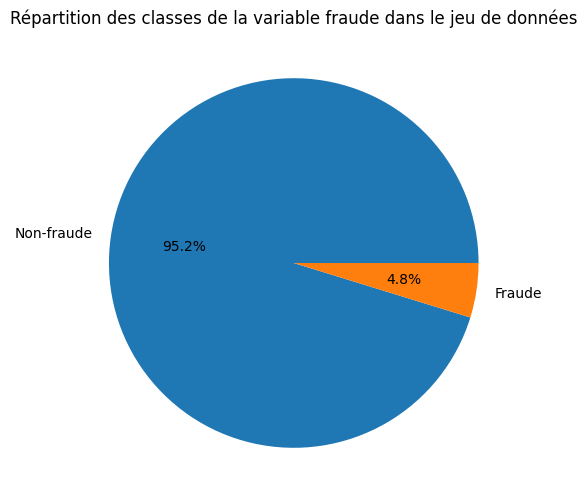

In [33]:
# On compte les classes et labels dans le jeu de données.
anomalies_counts = df['fraude'].value_counts().sort_index()
labels = ["Non-fraude", "Fraude"]

# On affiche le pie chart
plt.figure(figsize=(6,6))
plt.pie(
    anomalies_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=0
)
plt.title("Répartition des classes de la variable fraude dans le jeu de données")
plt.show()

La distribution montre que 95 % des transactions ne sont pas frauduleuses et seulement 5 % sont des fraudes.

Ainsi, le dataset est très déséquilibré, si on effectue un modèle de prédiction, celui-ci sera très certainement biaisé. Il faudrait donc effectuer une méthode de rééquilibrage au préalable.

### Question 1.3 (1 point)

**Vérifiez la présence de valeurs manquantes dans le jeu de données et indiquez, pour chaque variable, le nombre de valeurs manquantes éventuelles.**

In [34]:
missing = df.isnull().sum()

print("Nombre de valeurs manquantes par colonne :")
print(missing)
if missing.sum() == 0:
    print("\nAucune valeur manquante détectée.")
else:
    print("\nColonnes avec valeurs manquantes :")
    print(missing[missing > 0])

Nombre de valeurs manquantes par colonne :
transaction_id             0
date_heure                 0
client_id                  0
produit_id                 0
catégorie                  0
quantité                   0
prix_unitaire              0
moyen_paiement             0
ville                      0
âge_client                 0
ancienneté_compte_jours    0
fraude                     0
montant_total              0
dtype: int64

Aucune valeur manquante détectée.


On remarque qu'il n'y a aucune valeur manquante dans le dataset. On peut alors étudier statistiquement le jeu de données.

### Question 1.4 (3 points)

**Affichez des statistiques descriptives (moyenne, médiane, minimum, maximum, écart-type) pour les variables numériques, et visualisez-les à l’aide de boxplots.**

**Note** : Comme les variables peuvent avoir des échelles très différentes, assurez-vous de tracer les boxplots dans des graphiques séparés afin d’obtenir une visualisation claire et interprétable.

Colonnes numériques : ['transaction_id', 'quantité', 'prix_unitaire', 'âge_client', 'ancienneté_compte_jours', 'fraude', 'montant_total']


,n (nombre de transactions),moyenne,médiane,min,max,écart-type
variable,,,,,,
transaction_id,1050,10953.0714,10524.50,10000.00,20049.00,2047.9052
quantité,1050,3.7181,3.00,1.00,95.00,6.6687
prix_unitaire,1050,135.6835,103.13,10.04,4995.62,343.2463
âge_client,1050,43.8895,44.00,18.00,69.00,14.5845
ancienneté_compte_jours,1050,491.7000,495.00,1.00,999.00,286.5930
fraude,1050,0.0476,0.00,0.00,1.00,0.2130
montant_total,1050,428.6528,256.63,10.96,12517.05,904.4446


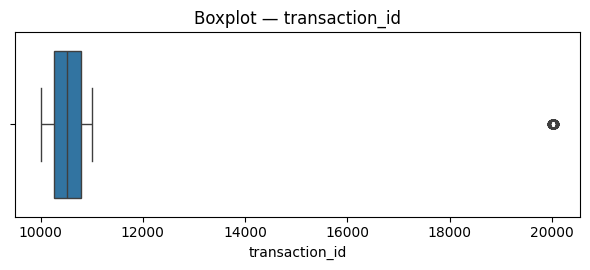

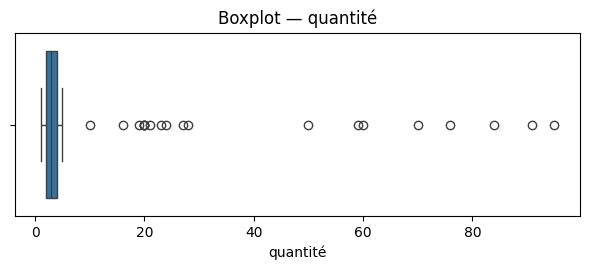

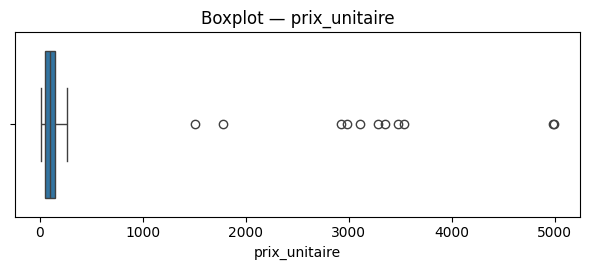

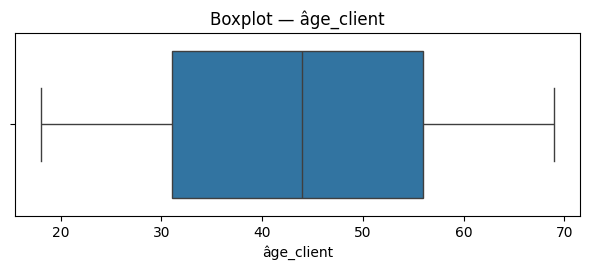

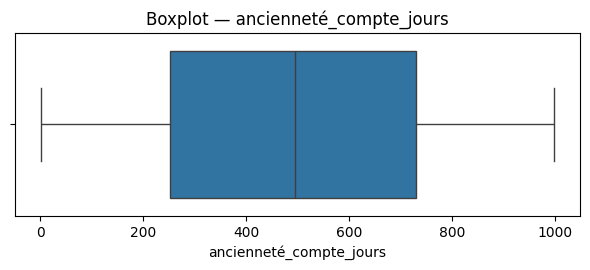

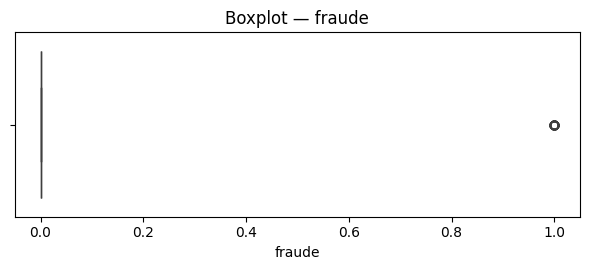

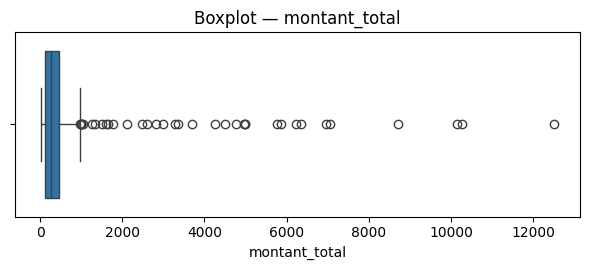

In [35]:
# On affiche les colonnes numériques pour vérification.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Colonnes numériques :", numeric_cols)

# On calcul les statistiques pertinentes sur le dataset, on stocke les résultats que l'on affiche dans un tableau.
stats = []
for c in numeric_cols:
    series = df[c].dropna()
    stats.append({
        'variable': c,
        'n (nombre de transactions)': int(series.count()),
        'moyenne': float(series.mean()) if series.size>0 else np.nan,
        'médiane': float(series.median()) if series.size>0 else np.nan,
        'min': float(series.min()) if series.size>0 else np.nan,
        'max': float(series.max()) if series.size>0 else np.nan,
        'écart-type': float(series.std(ddof=0)) if series.size>0 else np.nan
    })
stats_df = pd.DataFrame(stats).set_index('variable')
display(stats_df.round(4))

# Finalement, on affiche des boxplots avec un graphique séparé pour chaque variable numérique.
for c in numeric_cols:
    plt.figure(figsize=(6,2.8))
    sns.boxplot(x=df[c])
    plt.title(f"Boxplot — {c}")
    plt.xlabel(c)
    plt.tight_layout()
    plt.show()

### Question 1.5 (2 points)

**Pour les variables catégorielles, affichez les valeurs uniques, puis visualisez la répartition des catégories (en pourcentage) avec un pie chart ou un countplot. Veuillez exclure les variables de type ID de cette analyse.**

Colonnes catégorielles analysées : ['date_heure', 'catégorie', 'moyen_paiement', 'ville']

--- Variable : date_heure ---
Nombre de valeurs uniques : 582
Exemples de valeurs uniques : ['2023-06-08 12:00:00' '2023-05-29 19:00:00' '2023-05-08 13:00:00'
 '2023-06-08 18:00:00' '2023-05-19 15:00:00' '2023-05-11 19:00:00'
 '2023-05-24 13:00:00' '2023-06-05 16:00:00' '2023-05-24 11:00:00'
 '2023-05-22 13:00:00']

Répartition en pourcentage (top 10) :
date_heure
2023-05-26 13:00:00    0.67
2023-05-22 18:00:00    0.57
2023-06-27 11:00:00    0.48
2023-06-14 17:00:00    0.48
2023-06-23 16:00:00    0.48
2023-05-17 16:00:00    0.48
2023-06-23 14:00:00    0.48
2023-05-30 19:00:00    0.48
2023-06-06 17:00:00    0.48
2023-05-28 18:00:00    0.48
Name: proportion, dtype: float64


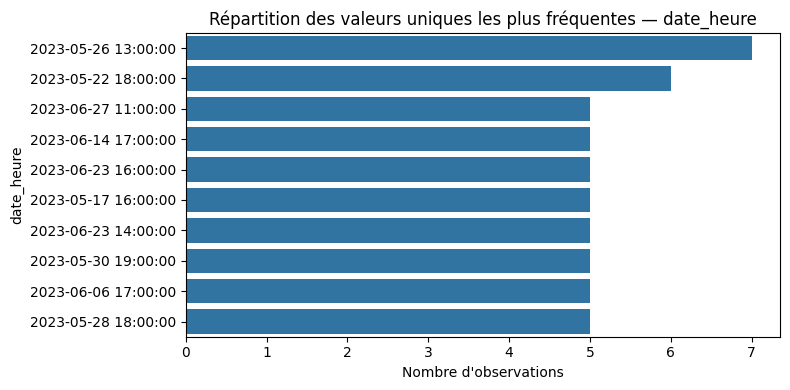


--- Variable : catégorie ---
Nombre de valeurs uniques : 4
Exemples de valeurs uniques : ['Décoration' 'Art de la table' 'Textile' 'Cuisine']

Répartition en pourcentage (top 10) :
catégorie
Art de la table    27.71
Textile            25.14
Cuisine            24.67
Décoration         22.48
Name: proportion, dtype: float64


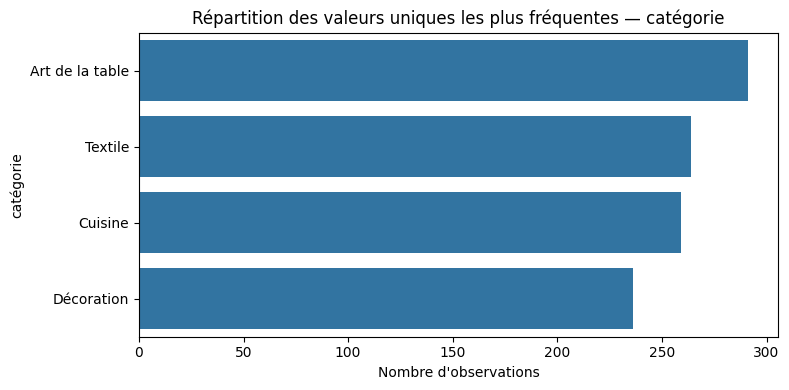


--- Variable : moyen_paiement ---
Nombre de valeurs uniques : 3
Exemples de valeurs uniques : ['PayPal' 'Virement' 'Carte']

Répartition en pourcentage (top 10) :
moyen_paiement
PayPal      36.19
Carte       32.67
Virement    31.14
Name: proportion, dtype: float64


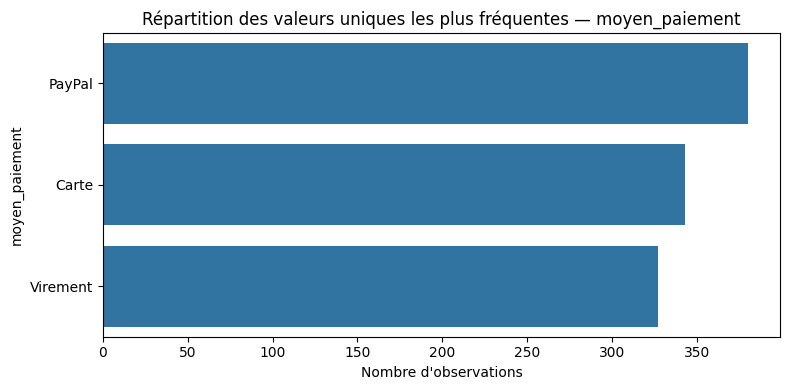


--- Variable : ville ---
Nombre de valeurs uniques : 5
Exemples de valeurs uniques : ['Toulouse' 'Bordeaux' 'Paris' 'Marseille' 'Lyon']

Répartition en pourcentage (top 10) :
ville
Lyon         22.57
Bordeaux     20.29
Paris        19.33
Marseille    19.14
Toulouse     18.67
Name: proportion, dtype: float64


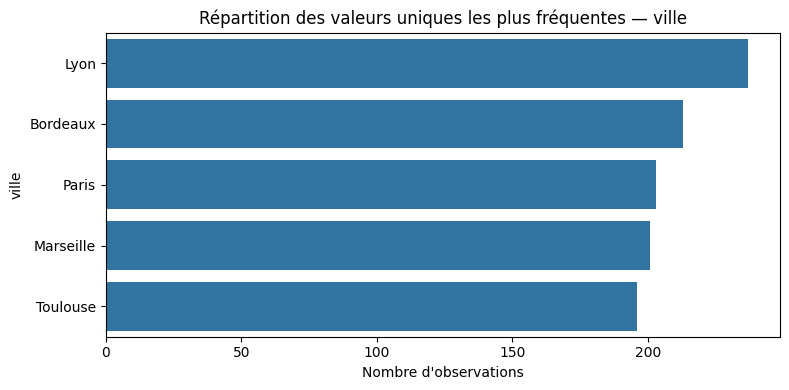

In [36]:
# On exclut les variables de type ID de cette analyse.
id_cols = ['transaction_id', 'client_id', 'produit_id']

# On détecte les colonnes catégorielles restantes.
cat_cols = [c for c in df.select_dtypes(include=['object','category']).columns if c not in id_cols]
print("Colonnes catégorielles analysées :", cat_cols)

# Pour chaque variable, on affiche les valeurs uniques, puis on calcule le pourcentage associé.
for col in cat_cols:
    print(f"\n--- Variable : {col} ---")

    # On affiche les valeurs uniques (nombre + top10).
    uniques = df[col].unique()
    print(f"Nombre de valeurs uniques : {len(uniques)}")
    print("Exemples de valeurs uniques :", uniques[:10]) # arbitrairement, on choisit un top10 pour plus de visualisation.

    # On calcule la répartition en pourcentage pour chaque valeurs uniques et on affiche seulement les plus pertinentes.
    pct = df[col].value_counts(normalize=True) * 100
    print("\nRépartition en pourcentage (top 10) :")
    print(pct.head(10).round(2))

    # On fait une visualisation de la répartition sous la forme d'un countplot (top 10 pour date_heure pour la lisibilité).
    plt.figure(figsize=(8,4))
    order = df[col].value_counts().index[:10]
    sns.countplot(y=col, data=df, order=order)
    plt.title(f"Répartition des valeurs uniques les plus fréquentes — {col}")
    plt.xlabel("Nombre d'observations")
    plt.tight_layout()
    plt.show()

## Partie 2 : Détection d'Anomalies Simple (10 points)

### Question 2.1 (5 points)

Implémentez la fonction `detect_anomalies_zscore` qui identifie et retourne les observations considérées comme des anomalies en se basant sur la méthode du **Z-Score**.

La fonction devra prendre en entrée un DataFrame \(data\), le nom de la colonne à analyser \(column\), et un seuil \(threshold\) (par défaut à 3).

Les observations dont la valeur absolue du Z-Score dépasse ce seuil seront considérées comme des anomalies.


In [37]:
# TO DO
def detect_anomalies_zscore(data, column, threshold=3):
    """
    Détecte les anomalies avec la méthode du Z-Score.

    Paramètres
    ----------
    data : DataFrame
        Données d’entrée.
    column : str
        Colonne cible.
    threshold : float
        Seuil Z-Score.

    Retourne
    --------
    DataFrame
        Lignes anormales.
    """
    # Au préalable, on calcule la moyenne et l'écart-type.
    mean = data[column].mean()
    std = data[column].std()

    # On calcule le Z-score.
    z_scores = (data[column] - mean) / std

    # On gère la sélection des anomalies en ne considérant que les valeurs dépassant le seuil.
    anomalies = data[np.abs(z_scores) > threshold]

    return anomalies

**Appliquez la fonction aux colonnes `montant_total` et `quantité`**.

In [38]:
# On applique la fonction aux colonnes montant_total et quantité.
anomalies_montant = detect_anomalies_zscore(df, "montant_total")
anomalies_quantite = detect_anomalies_zscore(df, "quantité")

# On affiche le nombre d'anomalies pour chaque colonne.
print("Anomalies sur 'montant_total' :", len(anomalies_montant))
display(anomalies_montant)

print("Anomalies sur 'quantité' :", len(anomalies_quantite))
display(anomalies_quantite)

Anomalies sur 'montant_total' : 19


,transaction_id,date_heure,client_id,produit_id,catégorie,quantité,prix_unitaire,moyen_paiement,ville,âge_client,ancienneté_compte_jours,fraude,montant_total
1000,20000,2023-05-24 00:00:00,C3010,P558,Décoration,1,4978.38,Virement,Lyon,69,585,1,4978.38
1001,20001,2023-05-01 00:00:00,C3016,P594,Textile,27,213.56,PayPal,Bordeaux,66,1,1,5766.12
1004,20004,2023-06-25 00:00:00,C3331,P567,Cuisine,1,3287.59,Carte,Lyon,62,447,1,3287.59
1005,20005,2023-06-09 00:00:00,C3811,P585,Textile,2,2927.98,Virement,Lyon,39,528,1,5855.96
1006,20006,2023-06-26 00:00:00,C3573,P581,Cuisine,91,137.55,PayPal,Lyon,40,359,1,12517.05
1010,20010,2023-06-06 00:00:00,C3467,P597,Décoration,70,145.11,PayPal,Lyon,23,635,1,10157.70
1015,20015,2023-06-10 00:00:00,C3338,P529,Art de la table,50,89.86,Virement,Marseille,41,743,1,4493.00
1017,20017,2023-05-07 00:00:00,C3986,P546,Art de la table,20,185.19,Virement,Bordeaux,39,2,1,3703.80
1019,20019,2023-05-10 00:00:00,C3328,P558,Cuisine,23,215.48,Carte,Marseille,19,1,1,4956.04
1020,20020,2023-06-19 00:00:00,C3791,P526,Art de la table,16,265.69,PayPal,Marseille,18,2,1,4251.04


Anomalies sur 'quantité' : 11


,transaction_id,date_heure,client_id,produit_id,catégorie,quantité,prix_unitaire,moyen_paiement,ville,âge_client,ancienneté_compte_jours,fraude,montant_total
1001,20001,2023-05-01 00:00:00,C3016,P594,Textile,27,213.56,PayPal,Bordeaux,66,1,1,5766.12
1002,20002,2023-06-22 00:00:00,C3973,P543,Cuisine,24,66.75,PayPal,Toulouse,58,2,1,1602.00
1006,20006,2023-06-26 00:00:00,C3573,P581,Cuisine,91,137.55,PayPal,Lyon,40,359,1,12517.05
1010,20010,2023-06-06 00:00:00,C3467,P597,Décoration,70,145.11,PayPal,Lyon,23,635,1,10157.70
1011,20011,2023-06-27 00:00:00,C3855,P512,Cuisine,28,75.24,Virement,Marseille,45,1,1,2106.72
1015,20015,2023-06-10 00:00:00,C3338,P529,Art de la table,50,89.86,Virement,Marseille,41,743,1,4493.00
1025,20025,2023-05-26 00:00:00,C3460,P558,Textile,60,105.77,Carte,Bordeaux,65,433,1,6346.20
1026,20026,2023-06-16 00:00:00,C3055,P564,Textile,84,103.63,Carte,Paris,59,672,1,8704.92
1036,20036,2023-06-13 00:00:00,C3867,P542,Art de la table,59,80.91,PayPal,Paris,26,957,1,4773.69
1042,20042,2023-05-17 00:00:00,C3934,P589,Textile,95,108.07,Virement,Bordeaux,38,979,1,10266.65


### Question 2.2 (5 points)

Implémentez la fonction `evaluate_performance` qui évalue la performance d'un modèle de détection d'anomalies.  

La fonction devra prendre en entrée les anomalies détectées et les vraies anomalies, puis calculer :  
- le nombre de vrais positifs et faux positifs,  
- la précision :  
  $
  \text{Precision} = \frac{VP}{VP + FP}
  $
- le rappel :  
  $
  \text{Rappel} = \frac{VP}{\text{Total Fraudes}}
  $

Elle retournera ces valeurs sous forme d'un dictionnaire pour analyser la qualité de la détection.



In [39]:
# TO DO
def evaluate_performance(anomalies_detectees, vraies_anomalies):
    """
    Évalue la performance de détection.

    Paramètres
    ----------
    anomalies_detectees : DataFrame
        Anomalies prédites.
    vraies_anomalies : DataFrame
        Anomalies réelles.

    Retourne
    --------
    dict
        Métriques d’évaluation.
    """
    # D'abord, on merge les deux dataFrames en entrée pour avoir les Vrais Positifs.
    VP = anomalies_detectees.merge(vraies_anomalies, on="transaction_id").shape[0]

    # Pour calculer les Faux Positifs, on prend les anomalies détectées mais qui ne sont pas des fraudes
    FP = len(anomalies_detectees) - VP

    # On calcule le nombre de fraudes au total
    total_fraudes = len(vraies_anomalies)

    # Cas limite, on évite une division par zéro
    precision = VP / (VP + FP) if (VP + FP) > 0 else 0
    rappel = VP / total_fraudes if total_fraudes > 0 else 0

    return {
        "Vrais positifs": VP,
        "Faux positifs": FP,
        "Précision": precision,
        "Rappel": rappel
    }

**Appliquez la fonction aux colonnes `montant_total` et `quantité`. Commentez brièvement.**

In [40]:
# On détermine les vraies anomalies pour pouvoir exécuter la fonction.
vraies_anomalies = df[df["fraude"] == 1]

# On applique la fonction pour les deux colonnes
perf_montant = evaluate_performance(anomalies_montant, vraies_anomalies)
perf_quantite = evaluate_performance(anomalies_quantite, vraies_anomalies)

print("Performance pour montant_total :")
print(perf_montant)

print("\nPerformance pour quantité :")
print(perf_quantite)

Performance pour montant_total :
{'Vrais positifs': 19, 'Faux positifs': 0, 'Précision': 1.0, 'Rappel': 0.38}

Performance pour quantité :
{'Vrais positifs': 11, 'Faux positifs': 0, 'Précision': 1.0, 'Rappel': 0.22}


On peut analyser les résultats obtenus :

Dans les deux cas, on constate aucun faux positif avec une précision de 1. Ainsi, le modèle ne se trompe jamais lorsqu'il détecte une anomalie. Toutes les transactions détectées comme anormales par le Z-Score sont réellement des fraudes.

Toutefois, dans les deux cas, le rappel est très faible (0,38 et 0,22). Le modèle détecte peu de fraudes existantes. La majorité des fraudes ne sont pas détéctées.

On constate que le modèle est plus performant avec montant_total (0,38) qu'avec quantité (0,22).

En majorité, les fraudeurs font des commandes avec des montants ou des quantités normales qui ne sont pas détectés par le modèle Z-score.

## Partie 3 : Détection d'Anomalies par Clustering (20 points)

### Question 3.1 (5 points)

Implémentez la fonction `preprocess_data` qui encode les variables catégorigues en utilisant le One-Hot Encoding et standardize les variables numériques.

**NB 1:** Les variables suivantes doivent être exclues: `date_heure`,
`client_id`, `produit_id`, `transaction_id` et `fraude`.

**NB 2:** Après l'encodage, supprimez la colonne correspondant à la première modalité de chaque variable catégorique pour éviter la multicolinéarité.

Affichez le nombre de colonnes et le type de chaque colonne avant et après le pré-traitement.

In [41]:
# TO DO
def preprocess_data(df):
    """
    Prépare les données pour l’analyse.

    Paramètres
    ----------
    df : DataFrame
        Données brutes.

    Retourne
    --------
    DataFrame
        Données prétraitées.
    """
    # On exclut les colonnes demandées par la consigne.
    cols_to_exclude = ["date_heure", "client_id", "produit_id", "transaction_id", "fraude"]
    df_clean = df.drop(columns=cols_to_exclude)

    # Affichage avant le pré-traitement des données.
    print("=== AVANT PRÉTRAITEMENT ===")
    print("Nombre de colonnes :", df_clean.shape[1])
    print(df_clean.dtypes)

    # On sépare les variables numériques et catégoriques
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    categorical_cols = df_clean.select_dtypes(exclude=[np.number]).columns

    # Variables catégoriques : One-Hot Encoding.
    # On utilise drop_first=True qui supprime la première modalité de chaque variable pour éviter la multicolinéarité
    df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

    # Variables numériques : Standardisation des valeurs.
    scaler = StandardScaler()
    df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

    # Affichage après le pré-traitement des données.
    print("\n=== APRÈS PRÉTRAITEMENT ===")
    print("Nombre de colonnes :", df_encoded.shape[1])
    print(df_encoded.dtypes)

    return df_encoded

In [42]:
# TO DO
preprocessed_df = preprocess_data(df)

=== AVANT PRÉTRAITEMENT ===
Nombre de colonnes : 8
catégorie                   object
quantité                     int64
prix_unitaire              float64
moyen_paiement              object
ville                       object
âge_client                   int64
ancienneté_compte_jours      int64
montant_total              float64
dtype: object

=== APRÈS PRÉTRAITEMENT ===
Nombre de colonnes : 14
quantité                   float64
prix_unitaire              float64
âge_client                 float64
ancienneté_compte_jours    float64
montant_total              float64
catégorie_Cuisine             bool
catégorie_Décoration          bool
catégorie_Textile             bool
moyen_paiement_PayPal         bool
moyen_paiement_Virement       bool
ville_Lyon                    bool
ville_Marseille               bool
ville_Paris                   bool
ville_Toulouse                bool
dtype: object


C'est cohérent avec le dataset initial (cf partie 1).

### Question 3.2 (5 points)

Déterminez le nombre optimal de clusters pour vos données prétraitées ``preprocessed_df`` en utilisant la méthode du score de silhouette avec ``KMeans``.

Pour faire ceci, testez les valeurs de $k$ comprises entre 2 et 10 et tracez le score de silhouette en fonction du nombre de clusters.  
Indiquez ensuite la valeur de $k$ qui maximise ce score.

**NB** : Lorsque vous utilisez ``KMeans``, ajoutez les paramètres ``random_state=42`` pour la reproductibilité des résultats, et ``n_init=10`` pour augmenter les chances d’obtenir un bon clustering (``KMeans`` est lancé 10 fois avec des initialisations différentes des centres pour garder la meilleure solution à la fin.).

Pour k = 2, le score de silhouette est : 0.7642
Pour k = 3, le score de silhouette est : 0.1760
Pour k = 4, le score de silhouette est : 0.1829
Pour k = 5, le score de silhouette est : 0.1675
Pour k = 6, le score de silhouette est : 0.1612
Pour k = 7, le score de silhouette est : 0.1627
Pour k = 8, le score de silhouette est : 0.1396
Pour k = 9, le score de silhouette est : 0.1333
Pour k = 10, le score de silhouette est : 0.1230


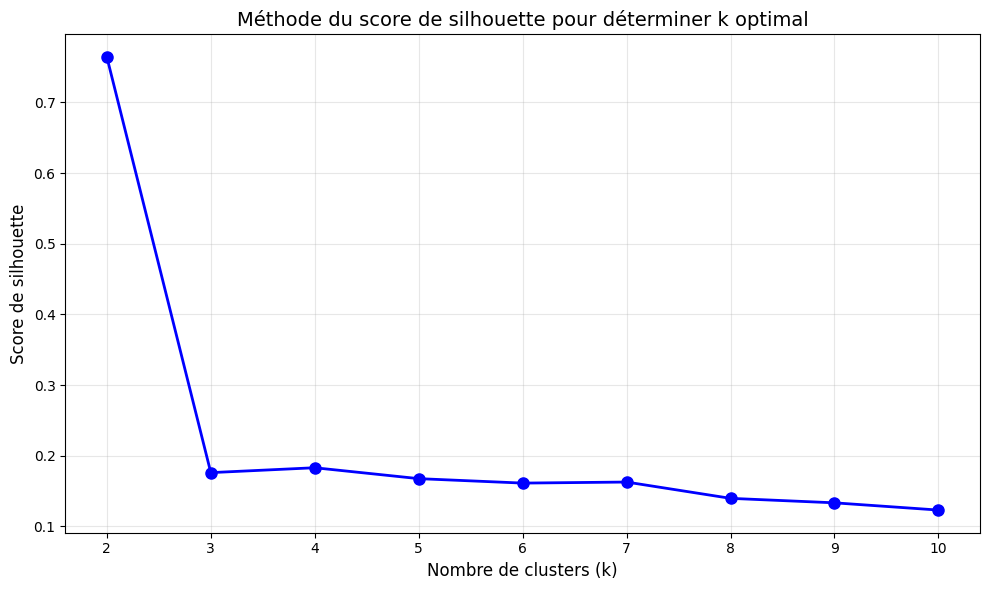


✓ Nombre optimal de clusters : k = 2
  Score de silhouette maximal : 0.7642


In [43]:
# On calcule les scores de silhouette pour k de 2 à 10
k_range = range(2, 11)
silhouette_scores = []

# On utilse la méthode du score de silhouette avec KMeans.
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # random_state = 42 pour la reproductibilité des résultats.
    # n_init = 10 pour augmenter les chances d'obtenir un bon clustering.
    cluster_labels = kmeans.fit_predict(preprocessed_df)
    silhouette_avg = silhouette_score(preprocessed_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Pour k = {k}, le score de silhouette est : {silhouette_avg:.4f}")

# On trace le graphique du score de silhouette en fonction du nombre de clusters
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Score de silhouette', fontsize=12)
plt.title('Méthode du score de silhouette pour déterminer k optimal', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

# On identifie le k optimal de manière numérique (on le vérifiera avec le graphique aussi)
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\n✓ Nombre optimal de clusters : k = {optimal_k}")
print(f"  Score de silhouette maximal : {max(silhouette_scores):.4f}")

Les résultats obtenus sont cohérents.

**Comparez le nombre optimal de clusters obtenu avec le nombre de classes dans la colonne `fraude`. Que remarquez-vous?**

In [44]:
# On compare le nombre optimal de clusters obtenu avec le nombre de classes dans fraude
n_classes_fraude = df['fraude'].nunique()
print(f"\nNombre de classes dans 'fraude' : {n_classes_fraude}")
print(f"Nombre optimal de clusters (k) : {optimal_k}")

if optimal_k == n_classes_fraude:
    print("\n✓ Le nombre optimal de clusters correspond au nombre de classes de fraude.")
else:
    print(f"\n⚠ Le nombre optimal de clusters ({optimal_k}) diffère du nombre de classes de fraude ({n_classes_fraude}).")


Nombre de classes dans 'fraude' : 2
Nombre optimal de clusters (k) : 2

✓ Le nombre optimal de clusters correspond au nombre de classes de fraude.


### Question 3.3 (5 points)

Appliquez `KMeans` avec le nombre de clusters $k$ retenu.  
Calculez ensuite le score d'outlier de chaque point en utilisant la distance de Mahalanobis.

La distance de Mahalanobis d'un point $X_i$ par rapport à son cluster $r$ est donnée par :

$$
\text{Maha}(X_i, \mu_r, \Sigma_r) = \sqrt{(X_i - \mu_r) \, \Sigma_r^{-1} \, (X_i - \mu_r)^T}
$$

où :  
- $X_i$ : point considéré  
- $\mu_r$ : centroïde du cluster $r$  
- $\Sigma_r$ : matrice de covariance des points dans le cluster $r$. Si $\Sigma_r$ n’est pas inversible, utilisez son pseudo-inverse.

In [46]:
# On applique KMeans avec k optimal obtenu à la question précédente
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(preprocessed_df)

mahalanobis_distances = []
# On calcule la distance de Mahalanobis pour chaque point
for i in range(len(preprocessed_df)):
    # Point actuel
    point = preprocessed_df.iloc[i].values

    # Cluster du point
    cluster_id = cluster_labels[i]

    # Points du même cluster
    cluster_mask = cluster_labels == cluster_id
    cluster_points = preprocessed_df[cluster_mask]

    # On calcule le centroïde du cluster
    centroid = cluster_points.mean().values

    # On calcule la matrice de covariance du cluster
    cov_matrix = cluster_points.cov().values

    # On vérifie si la matrice est inversible, sinon on utilise le pseudo-inverse
    try:
        cov_inv = np.linalg.inv(cov_matrix)
    except np.linalg.LinAlgError:
        cov_inv = np.linalg.pinv(cov_matrix)

    # Finalement, on calcule la distance de Mahalanobis
    diff = point - centroid
    maha_dist = np.sqrt(diff @ cov_inv @ diff.T)
    mahalanobis_distances.append(maha_dist)

# On convertit en array numpy les distances
mahalanobis_distances = np.array(mahalanobis_distances)

**Affichez la distribution des distances de Mahalanobis.**

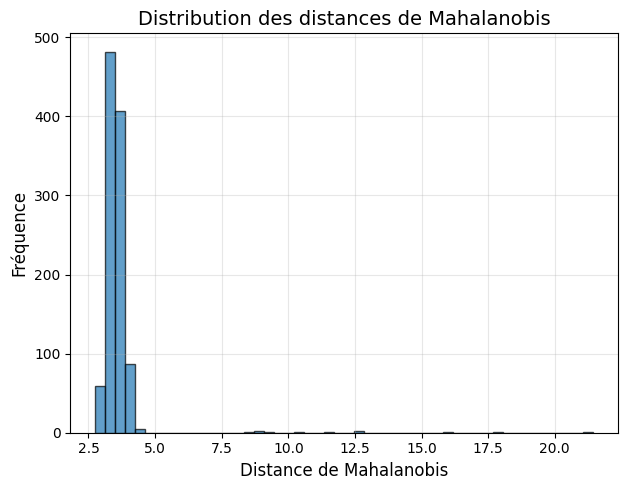

In [47]:
# Afficher la distribution des distances de Mahalanobis
plt.figure(figsize=(12, 5))

# Histogramme
plt.subplot(1, 2, 1)
plt.hist(mahalanobis_distances, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Distance de Mahalanobis', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution des distances de Mahalanobis', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La distribution est fortement asymétrique à gauche entre 2,5 et 5,0.

On constate des points qui sont très éloignées de la distribution normale avec des distances associées très élevées. Ces points extrêmes sont très éloignés du comportement typique de leur cluster.

Ils représentent des candidats naturels pour être des fraudes

### Question 3.4 (5 points)

À partir des scores de Mahalanobis calculés pour chaque point :  

1. Déterminez un seuil d’anomalie correspondant au 95ème percentile des distances.  
2. Détectez les points considérés comme anomalies en utilisant ce seuil (valeurs supérieures strictement).  
3. Évaluez la performance de la détection en comparant les anomalies détectées avec la colonne `fraude`.  
   - Calculez le nombre de vrais positifs, faux positifs, précision, rappel et F1-Score.
   - Commentez vos résultats.

In [50]:
# 1. On détermine le seuil correspondant au 95ème percentile).
threshold = np.percentile(mahalanobis_distances, 95)
print(f"Seuil d'anomalie (95ème percentile) : {threshold:.4f}")

# 2. On détecte les anomalies en utilisant le seuil précédent.
anomalies_detected = mahalanobis_distances > threshold
print(f"\nNombre d'anomalies détectées : {anomalies_detected.sum()}")

# 3. On évalue la performance de détection en comparant les anomalies détectées avec la colonne fraude.
y_true = df['fraude'].values
y_pred = anomalies_detected.astype(int)

# On calcule les métriques de performance de la détéction.
VP = np.sum((y_true == 1) & (y_pred == 1))  # Vrais positifs
FP = np.sum((y_true == 0) & (y_pred == 1))  # Faux positifs
FN = np.sum((y_true == 1) & (y_pred == 0))  # Faux négatifs
TN = np.sum((y_true == 0) & (y_pred == 0))  # Vrais négatifs
total_fraudes = np.sum(y_true == 1)

precision = VP / (VP + FP) if (VP + FP) > 0 else 0
rappel = VP / total_fraudes if total_fraudes > 0 else 0
f1 = 2 * (precision * rappel) / (precision + rappel) if (precision + rappel) > 0 else 0

# Affichage des métriques de performance de la détection.
print("\n=== MÉTRIQUES DE PERFORMANCE ===")
print(f"Vrais Positifs (VP)  : {VP}")
print(f"Faux Positifs (FP)   : {FP}")
print(f"Faux Négatifs (FN)   : {FN}")
print(f"Vrais Négatifs (TN)  : {TN}")
print(f"\nPrécision : {precision:.4f}")
print(f"Rappel    : {rappel:.4f}")
print(f"F1-Score  : {f1:.4f}")

Seuil d'anomalie (95ème percentile) : 3.9844

Nombre d'anomalies détectées : 53

=== MÉTRIQUES DE PERFORMANCE ===
Vrais Positifs (VP)  : 17
Faux Positifs (FP)   : 36
Faux Négatifs (FN)   : 33
Vrais Négatifs (TN)  : 964

Précision : 0.3208
Rappel    : 0.3400
F1-Score  : 0.3301


La performance globale du modèle est plutôt faible :
- Précision de 32% : Sur les 53 anomalies détectées, seulement 17 sont de vraies fraudes (32%). Les deux tiers (36) sont des faux positifs, c'est-à-dire des transactions normales incorrectement identifiées comme frauduleuses.
- Rappel de 34% : Sur les 50 fraudes réelles du dataset (17 + 33), la méthode n'en détecte que 17, soit environ un tiers. 66% des fraudes ne sont pas détectées (33 faux négatifs).
- F1-Score de 0.33 : Cette mesure équilibrée confirme une performance limitée du modèle.



## Partie 4 : Méthodes basées sur reconstruction (30 points)

Pour cette partie, vous allez implémenter un autoencodeur, un modèle d'apprentissage profond, pour repérer les comportements inhabituels dans les données.
L’objectif est de permettre au modèle d’apprendre la structure sous-jacente des transactions normales et de mettre en évidence celles qui s’en écartent significativement, indiquant ainsi une possible anomalie.

**NB** : Il s'agit d'un modèle d'apprentissage non supervisé, c'est-à-dire que les étiquettes indiquant la fraude (0 ou 1) ne doivent pas être utilisées pendant la phase d'entraînement.

### Question 4.1 (3 points)

Séparez les données (encodées et standardisées) en sous-ensemble d'entraînement et de test. Procédez comme suit :
* Utilisez 80 % des données non frauduleuses pour constituer l’ensemble d’entraînement.
* Conservez 20 % des données non frauduleuses pour l’ensemble de test.
* Ajoutez toutes les données frauduleuses à l’ensemble de test.

In [51]:
# On sépare les données non frauduleuses et frauduleuses
non_fraude = preprocessed_df[df['fraude'] == 0]
fraude = preprocessed_df[df['fraude'] == 1]

print(f"Nombre total de transactions : {len(preprocessed_df)}")
print(f"Transactions non frauduleuses : {len(non_fraude)}")
print(f"Transactions frauduleuses : {len(fraude)}")

# On sépare les données non frauduleuses en train/test (80/20)
X_train, X_test_non_fraude = train_test_split(non_fraude, test_size=0.2, random_state=42)

# On ajoute toutes les données frauduleuses à l'ensemble de test.
X_test = pd.concat([X_test_non_fraude, fraude], axis=0)

# On crée les labels pour le test
y_test = np.concatenate([
    np.zeros(len(X_test_non_fraude)),  # Non-fraudes
    np.ones(len(fraude))                # Fraudes
])

print(f"\n=== RÉPARTITION DES DONNÉES ===")
print(f"Ensemble d'entraînement : {len(X_train)} transactions (100% non frauduleuses)")
print(f"Ensemble de test : {len(X_test)} transactions")
print(f"  - Non frauduleuses : {len(X_test_non_fraude)} ({len(X_test_non_fraude)/len(X_test)*100:.1f}%)")
print(f"  - Frauduleuses : {len(fraude)} ({len(fraude)/len(X_test)*100:.1f}%)")

Nombre total de transactions : 1050
Transactions non frauduleuses : 1000
Transactions frauduleuses : 50

=== RÉPARTITION DES DONNÉES ===
Ensemble d'entraînement : 800 transactions (100% non frauduleuses)
Ensemble de test : 250 transactions
  - Non frauduleuses : 200 (80.0%)
  - Frauduleuses : 50 (20.0%)


### Question 4.2 (10 points)

Complétez la classe `Autoencoder` fournie. L'architecture du modèle doit respecter la structure suivante :
* Couche d'entrée :
  * Dimension égale au nombre de features du dataset `input_dim`.
* Encodeur :
  * Couche Dense avec `hidden_dim1` neurones, activation ReLU.
  * Batch Normalization.
  * Dropout avec un taux `dropout_rate` pour réduire le surapprentissage.
  * Couche Dense avec `hidden_dim2` neurones, activation ReLU.
  * Couche Dense avec `encoding_dim` neurones, activation ReLU.
* Décodeur (symétrique à l’encodeur), pas de normalisation batch ni de dropout.
  * Couche Dense avec `hidden_dim2` neurones, activation ReLU.
  * Couche Dense avec `hidden_dim1` neurones, activation ReLU.
  * Couche Dense avec `input_dim` neurones, activation linéaire.
* Compilez le modèle avec :
  * Optimiseur : Adam
  * Taux d’apprentissage : valeur passée en paramètre `learning_rate`
  * Fonction de perte : MSE (Mean Squared Error)
  * Métrique : MAE (Mean Absolute Error)

In [52]:
class Autoencoder:

    def __init__(self, input_dim, encoding_dim=7, hidden_dim1=32, hidden_dim2=16, learning_rate=0.001, dropout_rate=0.1):
        """
        Initialisation de l'autoencodeur.

        Paramètres
        ----------
        input_dim : int
            Dimension des données d'entrée.
        encoding_dim : int
            Dimension de l'espace latent (bottleneck).
        hidden_dim1 : int
            Taille de la première couche cachée.
        hidden_dim2 : int
            Taille de la deuxième couche cachée.
        learning_rate : float
            Taux d'apprentissage.
        dropout_rate : float
            Taux de dropout pour la régularisation.
        """
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.hidden_dim1 = hidden_dim1
        self.hidden_dim2 = hidden_dim2
        self.learning_rate = learning_rate
        self.dropout_rate = dropout_rate

        self.model = None

        self._build_autoencoder()

    def _build_autoencoder(self):
        """Construction de l'architecture de l'autoencodeur."""
        # Couche d'entrée
        # TO DO
        input_layer = Input(shape=(self.input_dim,))

        # Encodeur
        # TO DO
        encoded = Dense(self.hidden_dim1, activation='relu')(input_layer)
        encoded = BatchNormalization()(encoded)
        encoded = Dropout(self.dropout_rate)(encoded)
        encoded = Dense(self.hidden_dim2, activation='relu')(encoded)
        encoded = Dense(self.encoding_dim, activation='relu')(encoded)

        # Décodeur
        # TO DO
        decoded = Dense(self.hidden_dim2, activation='relu')(encoded)
        decoded = Dense(self.hidden_dim1, activation='relu')(decoded)
        decoded = Dense(self.input_dim, activation='linear')(decoded)

        # Modèle complet
        self.model = Model(inputs=input_layer, outputs=decoded)

        # Compilation
        # TO DO
        optimizer = Adam(learning_rate=self.learning_rate)
        self.model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    def summary(self):
        """Affiche le résumé du modèle complet."""
        # TO DO
        self.model.summary()

**Initialisez l'autoencodeur et vérifier que vous avez la bonne structure en affichant le `summary`. Vous disposez du résultats attendu dans la cellule suivante.**

In [53]:
# On initialise l'autoencodeur
input_dim = X_train.shape[1]
autoencoder = Autoencoder(input_dim=input_dim,
                          encoding_dim=7,
                          hidden_dim1=32,
                          hidden_dim2=16,
                          learning_rate=0.001,
                          dropout_rate=0.1)

# On affiche le summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           119 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,389 (9.33 KB)

 Trainable params: 2,325 (9.08 KB)

 Non-trainable params: 64 (256.00 B)

| Layer (type)                    | Output Shape | Param # |
|---------------------------------|--------------|---------|
| input_layer (InputLayer)        | (None, 14)   | 0       |
| dense (Dense)                   | (None, 32)   | 480     |
| batch_normalization (BatchNormalization) | (None, 32) | 128 |
| dropout (Dropout)               | (None, 32)   | 0       |
| dense_1 (Dense)                 | (None, 16)   | 528     |
| dense_2 (Dense)                 | (None, 7)    | 119     |
| dense_3 (Dense)                 | (None, 16)   | 128     |
| dense_4 (Dense)                 | (None, 32)   | 544     |
| dense_5 (Dense)                 | (None, 14)   | 462     |


C'est identique aux résultats de la cellule, on peut continuer.

### Question 4.3 (3 points)

Entraînez l’autoencodeur sur 50 époques en utilisant des lots de taille 32. Réservez 10% des données pour la validation **avec** mélange aléatoire (shuffle) des échantillons à chaque époque.

In [54]:
# On entraîne l'autoencodeur
history = autoencoder.model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.3316 - mae: 0.3805 - val_loss: 0.2831 - val_mae: 0.3285
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2683 - mae: 0.3501 - val_loss: 0.2599 - val_mae: 0.3379
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2314 - mae: 0.3538 - val_loss: 0.2361 - val_mae: 0.3382
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2010 - mae: 0.3416 - val_loss: 0.2134 - val_mae: 0.3322
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1779 - mae: 0.3274 - val_loss: 0.1928 - val_mae: 0.3258
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1597 - mae: 0.3153 - val_loss: 0.1706 - val_mae: 0.3141
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1467 - mae: 0.3051 - val_loss: 0.1553 - val_mae: 0.3026
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1380 - mae: 0.2935 - val_loss: 0.1433 - val_mae: 0.2929
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1304 - mae:

Tracez, sur un même graphique, les courbes de perte de l’autoencodeur pour l’entraînement et la validation en fonction des époques. Commentez brièvement.

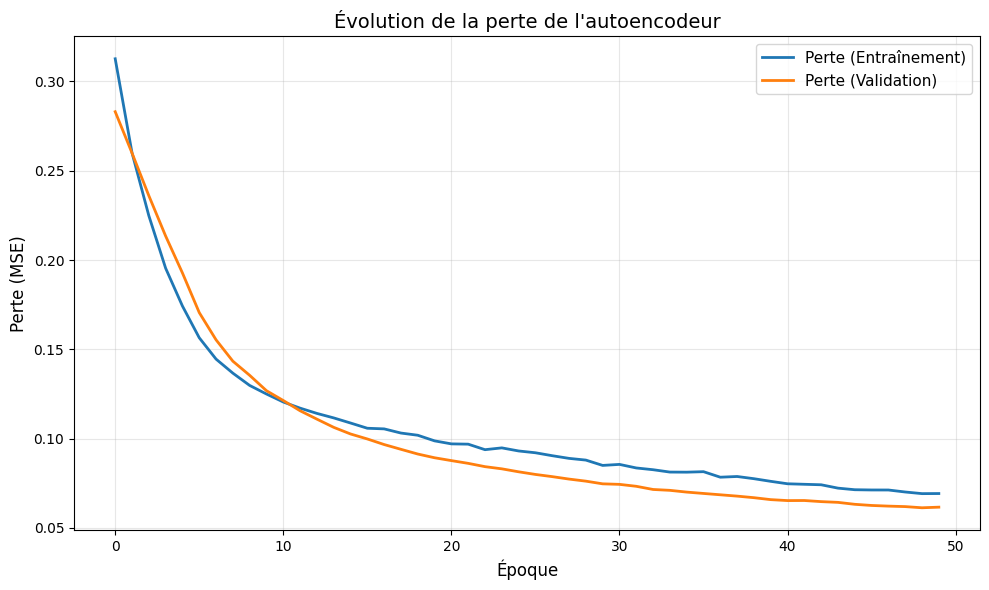

In [62]:
# On trace les courbes de perte sur le même graphique
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Perte (Entraînement)', linewidth=2)
plt.plot(history.history['val_loss'], label='Perte (Validation)', linewidth=2)
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Perte (MSE)', fontsize=12)
plt.title("Évolution de la perte de l'autoencodeur", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

L'autoencodeur montre un entraînement efficace avec une convergence rapide durant les 10 premières époques (perte passant de ~0.31 à ~0.12), suivie d'une stabilisation progressive jusqu'à environ 0.06-0.07.

Les courbes d'entraînement et de validation restent quasiment superposées tout au long de l'apprentissage, ce qui indique une excellente généralisation sans surapprentissage. L'absence d'oscillations et la diminution continue de la perte confirment que le modèle apprend efficacement la structure des transactions normales.

Cette convergence stable suggère que l'autoencodeur est bien configuré pour la détection d'anomalies.

### Question 4.4 (4 points)

L'erreur reconstruction de l'autoencodeur pour chaque donnée est calculée comme suit :\
$
\text{Erreur}_i = \sqrt{\sum_{k=1}^{d} (x_{ik} - \hat{x}_{ik})^2} = \| X_i - \hat{X}_i \|_2
$
où :
- $i$ est l'indice du point,  
- $d$ est le nombre de dimensions,  
- ${x}_{ik}$ est la valeur originale du point.
- $\hat{x}_{ik}$ est sa reconstruction par le modèle.

Calculez et affichez les erreurs de reconstruction pour les données de test.

In [64]:
# Reconstruire les données de test
X_test_reconstructed = autoencoder.model.predict(X_test, verbose=0)

# Calculer les erreurs de reconstruction (norme L2)
reconstruction_errors = ((X_test.values - X_test_reconstructed) ** 2).sum(axis=1) ** 0.5

print(f"\nStatistiques des erreurs de reconstruction :")
print(f"  Minimum    : {reconstruction_errors.min():.6f}")
print(f"  Maximum    : {reconstruction_errors.max():.6f}")
print(f"  Moyenne    : {reconstruction_errors.mean():.6f}")
print(f"  Médiane    : {reconstruction_errors[len(reconstruction_errors)//2]:.6f}")
print(f"  Écart-type : {reconstruction_errors.std():.6f}")


Statistiques des erreurs de reconstruction :
  Minimum    : 0.445290
  Maximum    : 19.237893
  Moyenne    : 1.888500
  Médiane    : 0.835884
  Écart-type : 3.191408


Affichez deux histogrammes représentant la distribution des erreurs de reconstruction : l’un pour les données normales, l’autre pour les données frauduleuses.
Comparez visuellement les deux distributions et commentez brièvement les différences observées.

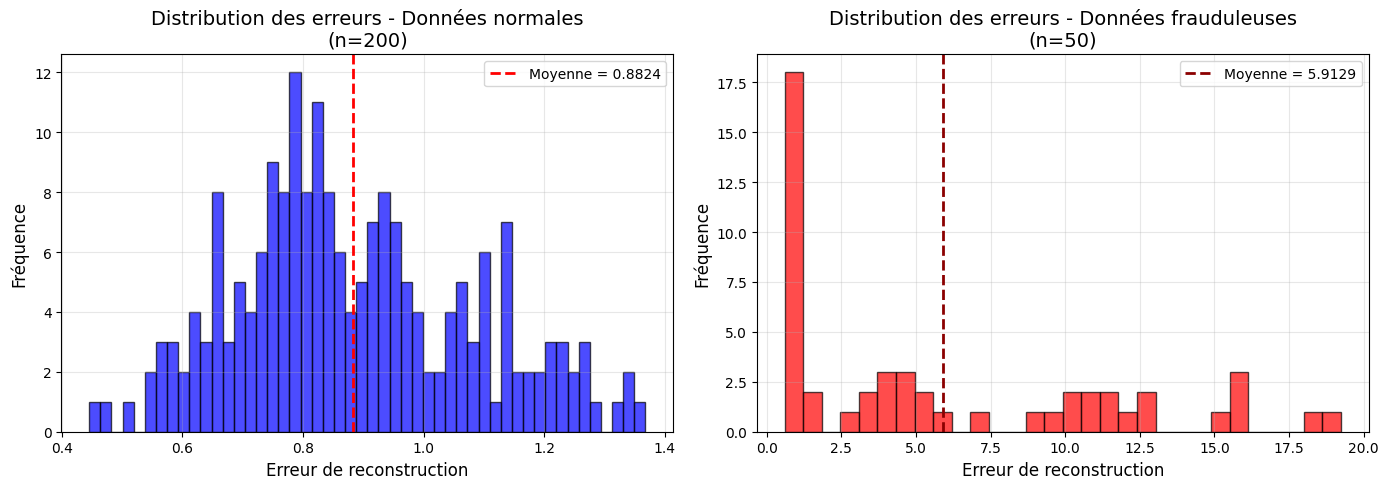

In [65]:
# On sépare les erreurs par classe
erreurs_normales = reconstruction_errors[y_test == 0]
erreurs_fraudes = reconstruction_errors[y_test == 1]

# On affiche les deux histogrammes
plt.figure(figsize=(14, 5))

# Histogramme pour les données normales
plt.subplot(1, 2, 1)
plt.hist(erreurs_normales, bins=50, edgecolor='black', alpha=0.7, color='blue')
plt.xlabel('Erreur de reconstruction', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title(f'Distribution des erreurs - Données normales\n(n={len(erreurs_normales)})', fontsize=14)
plt.axvline(np.mean(erreurs_normales), color='red', linestyle='--', linewidth=2, label=f'Moyenne = {np.mean(erreurs_normales):.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Histogramme pour les données frauduleuses
plt.subplot(1, 2, 2)
plt.hist(erreurs_fraudes, bins=30, edgecolor='black', alpha=0.7, color='red')
plt.xlabel('Erreur de reconstruction', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title(f'Distribution des erreurs - Données frauduleuses\n(n={len(erreurs_fraudes)})', fontsize=14)
plt.axvline(np.mean(erreurs_fraudes), color='darkred', linestyle='--', linewidth=2, label=f'Moyenne = {np.mean(erreurs_fraudes):.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Les deux distributions montrent une différence très marquée entre les transactions normales et frauduleuses. Les données normales présentent une distribution concentrée autour de 0.88, avec des erreurs variant principalement entre 0.6 et 1.2, ce qui indique que l'autoencodeur reconstruit fidèlement ces transactions. En revanche, les fraudes affichent une erreur moyenne de 5.91 (soit 6.7 fois plus élevée), avec une distribution beaucoup plus étalée allant jusqu'à 20. On constate donc deux comportement typiques en matière de fraudes : certaines fraudes relativement "discrètes" (erreurs entre 2-5) et d'autres très atypiques (erreurs > 10).

Cette séparation confirme que l'autoencodeur est efficace pour discriminer les fraudes. Toutefois, En ayant appris uniquement sur des transactions normales, le modèle ne parvient pas à reconstruire correctement les patterns frauduleux qui s'écartent significativement des comportements appris.

### Question 4.5 (4 points)

Pour détecter les anomalies à partir des erreurs de reconstruction, nous devons choisir un seuil qui permet de distinguer au mieux les données normales des données frauduleuses.

1. Utilisez la fonction `precision_recall_curve` de `scikit-learn` pour calculer la précision et le rappel pour différents seuils appliqués aux erreurs de reconstruction. (Nous comparons les erreurs de reconstruction avec les étiquettes réelles $y_{test}$).
2. À partir de ces valeurs, calculez le F1-score pour chaque seuil :
$
\text{F1-score} = \frac{2 \times \text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}}
$
3. Identifiez le seuil optimal qui maximise le F1-score.  
4. Tracez sur le même graphique les courbes de précision, rappel et f1-score puis indiquez le seuil optimal sur le graphique.

In [66]:
# 1. On utilise precision_recall_curve pour calculer précision et rappel pour différents seuils
precision, recall, thresholds = precision_recall_curve(y_test, reconstruction_errors)

# 2. On calcule le F1-score pour chaque seuil
f1_scores = 2 * (precision * recall) / (precision + recall)
# On gère les divisions par zéro (cas limite)
f1_scores = np.nan_to_num(f1_scores)

# 3. On identifie le seuil optimal qui maximise le F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precision[optimal_idx]
optimal_recall = recall[optimal_idx]

print(f"=== SEUIL OPTIMAL ===")
print(f"Seuil optimal : {optimal_threshold:.6f}")
print(f"F1-Score maximal : {optimal_f1:.4f}")
print(f"Précision : {optimal_precision:.4f}")
print(f"Rappel : {optimal_recall:.4f}")

=== SEUIL OPTIMAL ===
Seuil optimal : 1.402858
F1-Score maximal : 0.7805
Précision : 1.0000
Rappel : 0.6400


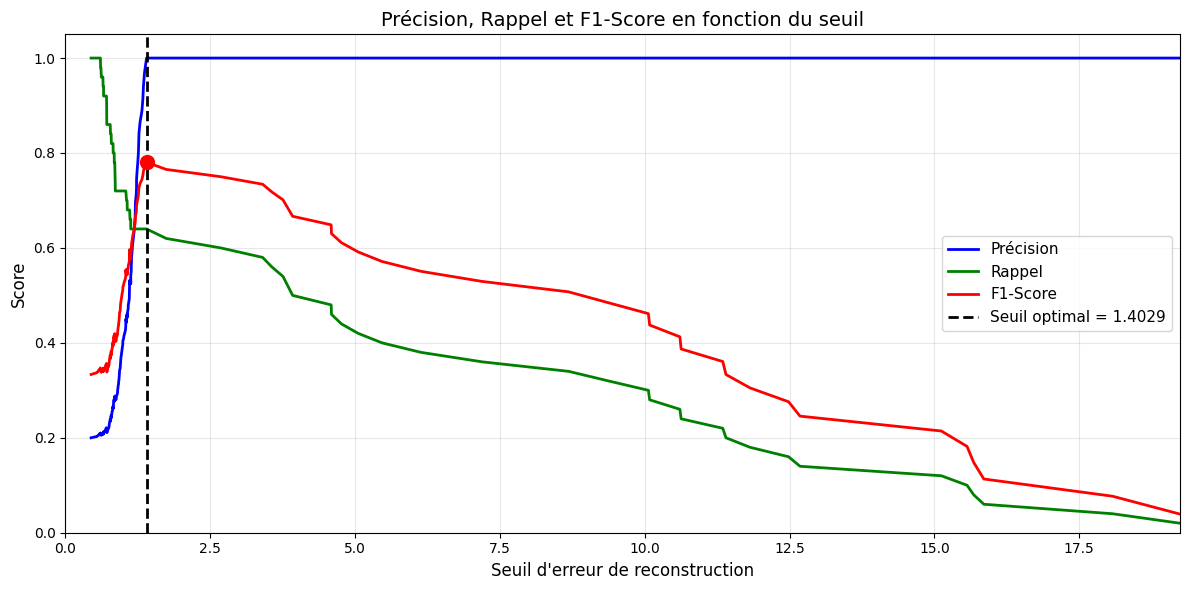

In [67]:
# 4. Maintenant, on peut tracer les courbes de précision, rappel et F1-score
plt.figure(figsize=(12, 6))

plt.plot(thresholds, precision[:-1], label='Précision', linewidth=2, color='blue')
plt.plot(thresholds, recall[:-1], label='Rappel', linewidth=2, color='green')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', linewidth=2, color='red')

# On indiquer le seuil optimal sur le graphique
plt.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2,
            label=f'Seuil optimal = {optimal_threshold:.4f}')
plt.scatter([optimal_threshold], [optimal_f1], color='red', s=100, zorder=5)

plt.xlabel('Seuil d\'erreur de reconstruction', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Précision, Rappel et F1-Score en fonction du seuil', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, max(thresholds[:len(f1_scores)-1]))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Question 4.6 (3 points)

Classez les observations du jeu de test en utilisant les erreurs de reconstruction et le seuil optimal déterminé précédemment. Si l’erreur dépasse ce seuil, l'observation est considérée comme anomalie. Affichez le rapport de classification et la matrice de confusion pour les données de test. Commentez brièvement.


=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

  Non-fraude       0.91      1.00      0.95       200
      Fraude       1.00      0.62      0.77        50

    accuracy                           0.92       250
   macro avg       0.96      0.81      0.86       250
weighted avg       0.93      0.92      0.92       250



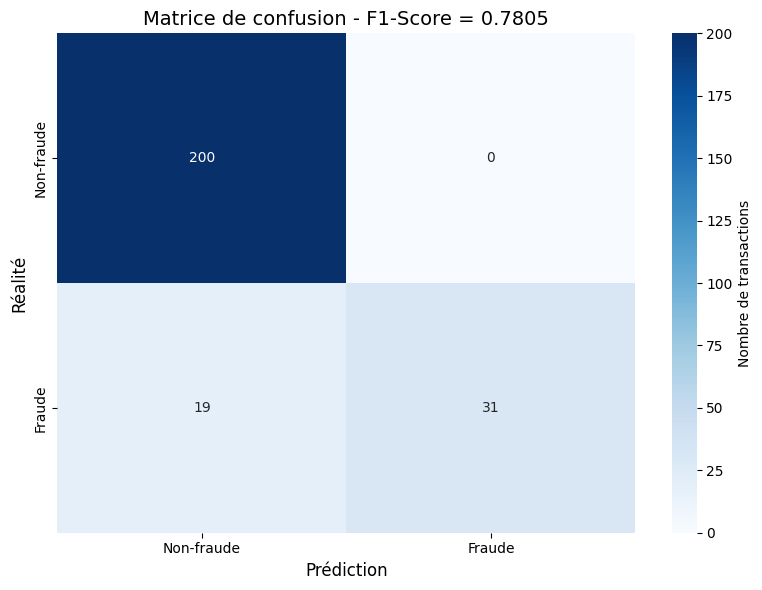

In [69]:
# On classe les observations en utilisant le seuil optimal obtenu juste au dessus
y_pred = (reconstruction_errors > optimal_threshold).astype(int)

# On affiche le rapport de classification
print("=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred, target_names=['Non-fraude', 'Fraude']))

# On afficher la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-fraude', 'Fraude'],
            yticklabels=['Non-fraude', 'Fraude'],
            cbar_kws={'label': 'Nombre de transactions'})
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Réalité', fontsize=12)
plt.title(f'Matrice de confusion - F1-Score = {optimal_f1:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

L'autoencodeur obtient d'excellents résultats avec un F1-Score de 0.78 pour les fraudes, nettement supérieur aux 0.33 obtenus avec KMeans+Mahalanobis.

La matrice de confusion révèle que le modèle détecte 31/50 fraudes (62% de rappel) avec une précision parfaite de 100% sur les fraudes détectées, et aucun faux positif parmi les transactions normales.

Cependant, 19 fraudes restent non détectées (38%), probablement celles ayant des patterns proches des comportements normaux. La performance globale (accuracy=92%, weighted F1=0.92) confirme que l'approche par reconstruction est très efficace : l'autoencodeur a bien appris la structure des transactions légitimes et identifie les comportements frauduleux par leurs erreurs de reconstruction élevées.

### Question 4.7 (3 points)

**Répondez aux questions suivantes :**
* Pourquoi utilise-t-on seulement les données normales pour l'entraînement ?
* Quelle est l'utilité de la couche bottleneck (encoding_dim) ?
* L'erreur de reconstruction est-elle un bon indicateur d'anomalie ? Justifiez votre réponse.

**Pourquoi utilise-t-on seulement les données normales pour l'entraînement ?**

On utilise uniquement les données normales car l'objectif est d'apprendre la structure et les patterns des transactions légitimes. L'autoencodeur se spécialise à reconnaître des comportements normaux. Lorsqu'il rencontre une transaction frauduleuse qu'il n'a jamais vue, il ne sait pas comment la reconstruire correctement, ce qui génère une erreur de reconstruction élevée. Si on incluait les fraudes à l'entraînement, le modèle apprendrait aussi à les reconstruire, perdant ainsi sa capacité à les détecter comme anomalies. Cette approche non supervisée est particulièrement utile dans les contextes de détection de fraude où les exemples frauduleux sont rares et en constante évolution.

**Quelle est l'utilité de la couche bottleneck (encoding_dim) ?**

La couche bottleneck de dimension 7 force l'autoencodeur à compresser l'information des 14 features d'entrée dans un espace réduit. Cette compression oblige le modèle à n'extraire que les caractéristiques essentielles et les patterns principaux des données normales, en ignorant le bruit et les variations mineures. C'est cette contrainte dimensionnelle qui permet de mieux détecter les anomalies : les fraudes, ayant des patterns différents, ne peuvent pas être bien représentées dans cet espace latent optimisé pour les transactions normales.

Toutefois, si on compresse trop alors le modèle perd en capacité pour pouvoir reconnaître des transactions normales. Il faut alors trouver un juste milieu.

**L'erreur de reconstruction est-elle un bon indicateur d'anomalie ?**

Oui, dans ce cas l'erreur de reconstruction est un excellent indicateur d'anomalie. Les résultats montrent que les fraudes ont une erreur moyenne 6.7 fois plus élevée que les transactions normales (5.91 vs 0.88), avec une séparation claire entre les deux distributions. Cette différence significative indique que les fraudes présentent des patterns suffisamment différents pour être mal reconstruites par un modèle entraîné uniquement sur des données normales.

Toutefois, dans un cas où les fraudes sont très subtiles, cette approche n'arrive pas à identifier ces exemples comme problématiques.

## Partie 5 : Etude d'ablation (20 points)

Dans cette partie, vous allez implémenter une étude d'ablation en utilisation votre autoencodeur. L'objectif est d’évaluer l’importance de chaque variable d’entrée du modèle. La méthodologie est simple: il faut retirer une variable à la fois, réentraîner l’autoencodeur, puis comparer la performance obtenue avec celle du modèle complet.

### Question 5.1 (5 points)

Complétez la fonction `evaluate_with_fixed_threshold`, dont la signature est fournie dans le code, pour évaluer la performance de l’autoencodeur en utilisant un seuil fixe pour la détection d’anomalies.
Cette fonction doit :  
- Calculer les erreurs de reconstruction pour chaque observation du jeu de test.  
- Classer les observations comme normales ou anomalies selon si leur erreur dépasse le seuil fixé.
- Calculer et retourner les principales métriques de performance : précision, rappel et F1-score.  

In [ ]:
# TO DO
def evaluate_with_fixed_threshold(autoencoder, X_test, y_test, threshold):
    """
    Évalue l'autoencodeur avec un seuil de décision fixé

    Paramètres:
    autoencoder: modèle autoencodeur entraîné
    X_test: données de test
    y_test: labels réels
    threshold: seuil fixe pour la détection d'anomalies

    Retourne:
    metrics: dictionnaire des métriques de performance
    """
    pass

### Question 5.2 (6 points)

Complétez la fonction `run_ablation_study_fixed_threshold` pour réaliser une étude d’ablation. Cette fonction doit :  
- Utiliser le modèle de référence (baseline) entraîné avec toutes les variables et évaluer sa performance avec le seuil fixe.  
- Répéter l’expérience en supprimant une variable à la fois du jeu de données :  
  - Initialiser et entraîner un nouvel autoencodeur sans la variable supprimée.
  - Évaluer le modèle avec le même seuil fixe.  
  - Mesurer l’impact de la suppression sur les métriques (en particulier le F1-score).  
- Retourner un `DataFrame` qui résume la baisse de performance pour chaque variable retirée. La première colonne doit contenir le nom de la variable supprimée. Les colonnes suivantes doivent présenter la différence entre les valeurs des métriques obtenues après la suppression de la variable et celles du modèle de base (baseline). Ajoutez également des colonnes contenant les valeurs absolues des métriques calculées.

In [ ]:
# TO DO
def run_ablation_study_fixed_threshold(autoencoder_baseline, X_train, X_test, y_test,
                                       feature_names, fixed_threshold):
    """
    Réalise une étude d'ablation avec seuil de décision fixe

    Paramètres:
    fixed_threshold: seuil fixe utilisé pour toutes les évaluations
    autoencoder_baseline: modèle de référence entraîné avec toutes les variables
    X_train: données d'entraînement
    X_test: données de test
    y_test: labels réels
    feature_names: liste des noms des variables
    encoding_dim: dimension de l'espace latent

    Retourne:
    ablation_results: DataFrame avec les résultats pour chaque variable retirée
    """
    pass

### Question 5.3 (3 points)

Exécutez l'étude d'ablation en utilisant la fonction `run_ablation_study_fixed_threshold` afin de mesurer l'importance des variables suivantes : `'quantité'`, `'prix_unitaire'`, `'montant_total'`, `'âge_client'`, `'ancienneté_compte_jours'`, et `'ecart_localisation'`. Utilisez votre meilleur seuil de la question $Q4.5$ et affichez le dataframe obtenu.

In [ ]:
# TO DO

### Question 5.4 (4 points)

Complétez la fonction `plot_ablation_results` pour visualiser les résultats de l'étude d'ablation. Cette fonction contient deux graphiques. Le premier montre la baisse du F1-score après la suppression de chaque variable. Le second affiche les valeurs absolues du F1-score obtenues après la suppression de chaque variable, avec une ligne en pointillés représentant le F1-score du modèle de base (baseline).  


In [ ]:
# TO DO
def plot_ablation_results(ablation_results, baseline_f1_score):
    """
    Visualise les résultats de l'étude d'ablation

    Paramètres:
    ablation_results: DataFrame avec les résultats pour chaque variable retirée
    baseline_f1_score: F1-score du modèle de base (baseline)
    """
    pass

In [ ]:
# TO DO

### Question 5.5 (2 points)

A partir du graphique précédent ou en utilisant du code, identifiez les variables dont la suppression entraîne une perte de 0.03 ou plus dans le F1-score. Commentez brièvement.

In [ ]:
# TO DO

## Partie 6 : Local Outlier Factor - LOF (10 points)

Pour la dernière partie du TP, vous allez détecter les anomalies frauduleuses en utilisant une technique basée sur la densité : **Facteur Local d’Aberration (Local Outlier Factor)**. Cette technique utilise la densité locale autour d’un point pour déterminer s’il est isolé par rapport à ses voisins proches. I.e., un point est considéré aberrant s'il est situé dans une région où la densité locale est nettement plus faible que celle de ses voisins, ce qui fait que son score LOF est plus élevé. Cette technique a donc l'avantage de pouvoir détecter les anomalies locales contrairement aux méthodes globales.
Pour calculer le facteur d'aberration d'un point $i$, il faut suivre les étapes suivantes :
1. Il faut identifier les k points les plus proches selon une distance (euclidienne dans le cadre du TP).
2. Il faut ensuite calculer la distance de portée (reachability distance) qui mesure à quel point le point $i$ est accessible à partir de ses voisins. La distance de portée entre les points $i$ et et l'un de ses voisin $j$ est définie comme la plus grande valeur entre la distance euclidienne $d(i,j)$ et la distance séparant $j$ de son $k$-ème plus proche voisin.\
$\text{RD(i,j)} = \max\left(d(i,j), \; d_k(j)\right)$

4. La troisième étape consiste à calculer la densité locale (Local Reachability Density – LRD) du point. Il s'agit de la moyenne des distances de portée entre le point en question et ses $k$ plus proches voisins.
5. Finalement, le facteur local d'aberration du point est calculé comme suit :
$
\text{LOF}(i) = \frac{\text{Moyenne des densités locales des voisins de} i}{\text{densité locale de } i}
$

**NB1:** Les formules mathématiques de chaque étape sont définies dans les questions associées.\
**NB2:** Les étapes 2 et 3 sont calculées conjointement dans la deuxième question.

**Sources**
- [Breunig, M. M., Kriegel, H. P., Ng, R. T., & Sander, J. (2000, May). LOF: identifying density-based local outliers. In Proceedings of the 2000 ACM SIGMOD international conference on Management of data (pp. 93-104).](https://doi.org/10.1145/342009.335388)
- [Explication pas-à-pas de l'algorithme LOF.](https://www.kaggle.com/discussions/general/183478)

### Question 6.1 (2 points)

Complétez les fonctions suivantes :
- `compute_distances` qui retourne une matrice carré contenant la distance euclidienne entre chaque paire de points.
- `find_k_neighbors` qui accèpte la matrice de distance calculée et le nombre de voisins souhaités et retourne pour chaque point les indices des ses $k$ plus proches voisins et la distance au $k$-ème voisin.

In [ ]:
def compute_distances(X):
    """
    Calcule la matrice de distance entre chaque paire de points.

    Paramètres:
    X: données d'entrée

    Retourne:
    matrice de distances
    """
    pass

In [ ]:
def find_k_neighbors(dist_matrix, k):
    """
    Identifie les k plus proches voisins pour chaque point.

    Paramètres :
    dist_matrix : matrice de distances (n x n)
    k : nombre de voisins

    Retourne :
    neighbors : indices des k voisins les plus proches
    k_distances : distance au k-ième voisin
    """
    pass

### Question 6.2 (2 points)

Complétez la fonction `compute_lrd` qui retourne la densité locale (Local Reachability Density) par point.

La densité locale d'un point $i$ est définie par:

$\text{LRD}(i) = \frac{k}{\sum_{j \in N_k(i)} \max\{\text{distance}(i,j), \text{k\_distance}(j)\}}$

où:  
- $k$ est le nombre de voisins les plus proches,  
- $N_k(i)$ est l'ensemble des indices des $k$ plus proches voisins du point $i$,  
- $\text{distance}(i,j)$ est la distance entre les points $i$ et $j$,  
- $\text{k\_distance}(j)$ est la distance du point $j$ à son $k$-ième voisin.

In [ ]:
def compute_lrd(dist_matrix, neighbors, k_distances):
    """
    Calcule la densité locale de chaque point (Local Reachability Density).

    Paramètres:
    dist_matrix : matrice des distances entre chaque paire de points
    neighbors : indices des k plus proches voisins de chaque point
    k_distances : distance au k-ième voisin pour chaque point

    Retourne:
    lrd : densité locale de chaque point
    """
    pass

### Question 6.3 (2 points)

Complétez la fonction `compute_lof` qui retourne le facteur d’éloignement local (Local Outlier Factor, LOF) par point.

La facteur d’éloignement local d'un point $i$ est défini par:

$$
\text{LOF}(i) = \frac{1}{k} \frac{\sum_{j \in N_k(i)} \text{LRD}(j)}{\text{LRD}(i)}
$$

où:  
- $k$ est le nombre de voisins les plus proches,  
- $N_k(i)$ est l'ensemble des indices des $k$ plus proches voisins du point $i$,  
- $\text{LRD}(i)$ est la densité locale du point $i$.

In [ ]:
def compute_lof(lrd, neighbors):
    """
    Calcule le score LOF (Local Outlier Factor) pour chaque point.

    Paramètres :
        lrd : Densité de proximité locale de chaque point.
        neighbors : Indices des k plus proches voisins pour chaque point.

    Retourne :
        lof : Score LOF pour chaque point
    """
    pass

### Question 6.4 (1 point)

Calculez les facteurs LOF pour chaque point des données. Fixez le $k$ comme étant la racine carrée du nombre total de points.

Définissez un seuil d’anomalie à partir du 95ᵉ percentile des scores LOF, puis identifiez les points considérés comme anomalies.

In [ ]:
# TO DO

### Question 6.5 (1 point)

Affichez la matrice de confusion et les métriques nécessaires (précision, rappel et f1-score). Commentez brièvement vos résultats.

In [ ]:
# TO DO

### Question 6.6 (2 points)

Affichez les 10 premiers outliers pour chaque méthode abordée. Est-ce qu'il s'agit des mêmes données ? Sinon, selon vous, quelle est la cause de cette divergence ?

In [ ]:
# TO DO